## Logistic Regression

In [1]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append("..")

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler

from src.evaluation import *
from src.visualization import plot_metric_surface

import warnings
warnings.filterwarnings("ignore")

In [2]:
x_train = pd.read_csv("../data/x_train.txt", sep=" ")
y_train = pd.read_csv("../data/y_train.txt")

scaler = MinMaxScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)

y_train = y_train.squeeze()

In [3]:
feature_importance_df = pd.read_csv("../outputs/feature_importance_ranking.csv")

**Logistic Regression** was treated primarily as a baseline model rather than a method expected to fully capture potentially complex relationships present in the dataset.

The model was trained iteratively using increasing numbers of top-ranked variables. Two independent ranking approaches were tested:

* features selected according to l1_rank,
* features selected according to avg_normalized_rank.

For each configuration, we evaluated:

- different regularization strengths (C values),
- varying numbers of selected features,
- different campaign targeting thresholds (top_n customers receiving the offer).

#### l1_rank

In [ ]:
C_VALUES = [5, 10, 20]
K_VALUES = range(1, 31)
TOP_N_VALUES = [250, 500, 750, 900, 950, 1000]

sorted_features = feature_importance_df.sort_values("l1_rank")["feature"].values

all_results = []

for C in C_VALUES:
    print(f"Running: C={C}")

    for k in K_VALUES:

        for t in TOP_N_VALUES:
            selected_features = sorted_features[:k]
            X_sel = x_train_scaled[selected_features]

            model = LogisticRegression(
                C=C,
                penalty="l2",
                solver="lbfgs",
                max_iter=10_000,
            )

            summary = cross_val_eval(
                model=model, X=X_sel, y=y_train,
                n_features=k, model_name=f"logreg_C={C}_k={k}",
                top_n=t, scaled_features=True)

            summary["C"] = C

            all_results.append(summary)

final_results = pd.DataFrame(all_results)

Running: C=5
Running: C=10
Running: C=20


In [5]:
final_results.sort_values(by="score", ascending=False).head(10)

,accuracy,precision,recall,f1,profit,score,n_features,accuracy_std,precision_std,recall_std,f1_std,profit_std,score_std,model,threshold,top_n,C
383,0.5732,0.677000,0.272111,0.388193,1031.0,871.0,4,0.014096,0.034749,0.014086,0.020046,104.247302,104.247302,logreg_C=20_k=4,None,1000,20
23,0.5728,0.676000,0.271708,0.387619,1028.0,868.0,4,0.014890,0.036810,0.014898,0.021210,110.430974,110.430974,logreg_C=5_k=4,None,1000,5
203,0.5724,0.675000,0.271307,0.387046,1025.0,865.0,4,0.014809,0.036572,0.014810,0.021082,109.715541,109.715541,logreg_C=10_k=4,None,1000,10
202,0.5716,0.682105,0.260453,0.376966,994.0,834.0,4,0.011845,0.030824,0.011849,0.017117,87.849303,87.849303,logreg_C=10_k=4,None,950,10
22,0.5716,0.682105,0.260453,0.376966,994.0,834.0,4,0.011845,0.030824,0.011849,0.017117,87.849303,87.849303,logreg_C=5_k=4,None,950,5
377,0.5628,0.651000,0.261664,0.373288,953.0,833.0,3,0.018780,0.046287,0.018759,0.026698,138.861442,138.861442,logreg_C=20_k=3,None,1000,20
29,0.5732,0.677000,0.272110,0.388192,1031.0,831.0,5,0.015023,0.037182,0.015038,0.021414,111.545955,111.545955,logreg_C=5_k=5,None,1000,5
389,0.5732,0.677000,0.272111,0.388193,1031.0,831.0,5,0.014096,0.034749,0.014086,0.020046,104.247302,104.247302,logreg_C=20_k=5,None,1000,20
382,0.5712,0.681053,0.260051,0.376385,991.0,831.0,4,0.012029,0.031270,0.012027,0.017371,89.120705,89.120705,logreg_C=20_k=4,None,950,20
197,0.5624,0.650000,0.261262,0.372714,950.0,830.0,3,0.019113,0.047170,0.019103,0.027193,141.509717,141.509717,logreg_C=10_k=3,None,1000,10


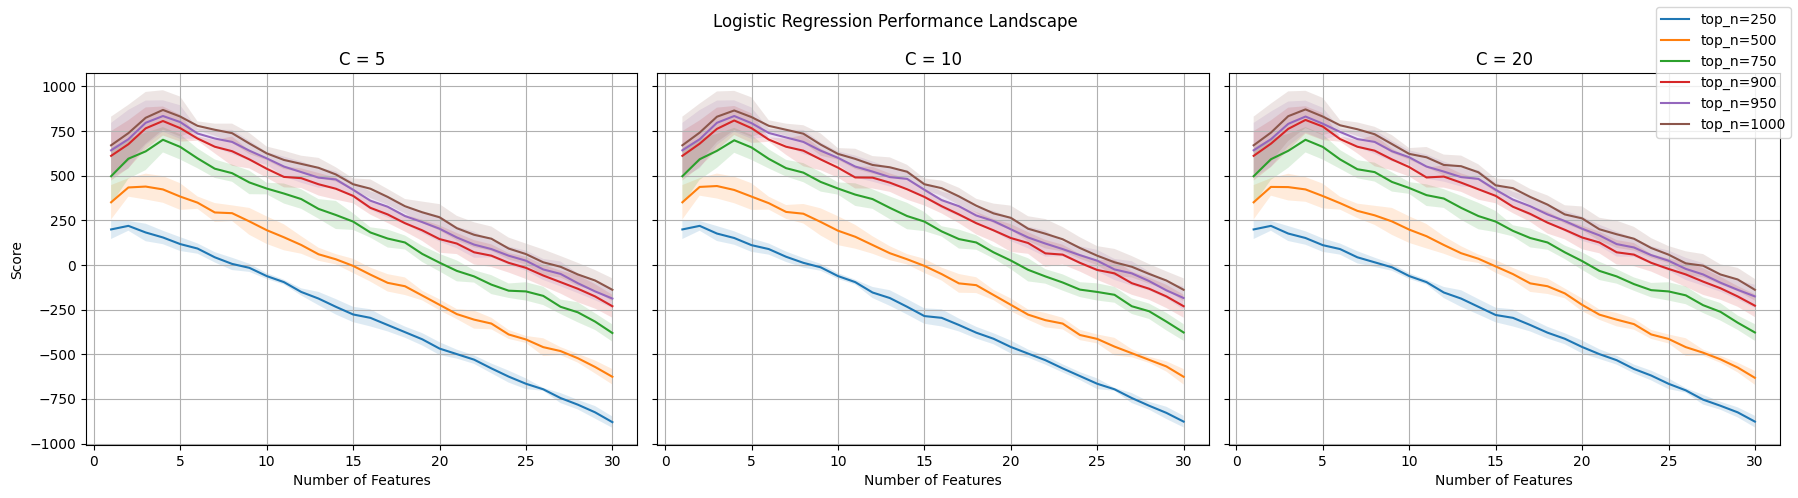

In [ ]:
plot_metric_surface(
    df=final_results,
    x_col="n_features",
    y_col="score",
    split_col="C",
    line_col="top_n",
    std_col="score_std",
    title="Logistic Regression Performance",
    x_label="Number of Features",
    y_label="Score"
)

#### avg_normalized_rank

In [7]:
C_VALUES = [5, 10, 20]
K_VALUES = range(1, 31)
TOP_N_VALUES = [250, 500, 750, 900, 950, 1000]

sorted_features = feature_importance_df.sort_values("avg_normalized_rank")["feature"].values

all_results = []

for C in C_VALUES:
    print(f"Running: C={C}")

    for k in K_VALUES:

        for t in TOP_N_VALUES:
            selected_features = sorted_features[:k]
            X_sel = x_train_scaled[selected_features]

            model = LogisticRegression(
                C=C,
                penalty="l2",
                solver="lbfgs",
                max_iter=10_000,
            )

            summary = cross_val_eval(
                model=model, X=X_sel, y=y_train,
                n_features=k, model_name=f"logreg_C={C}_k={k}",
                top_n=t, scaled_features=True)

            summary["C"] = C

            all_results.append(summary)

final_results = pd.DataFrame(all_results)

Running: C=5
Running: C=10
Running: C=20


In [9]:
final_results.sort_values(by="score", ascending=False).head(10)

,accuracy,precision,recall,f1,profit,score,n_features,accuracy_std,precision_std,recall_std,f1_std,profit_std,score_std,model,threshold,top_n,C
209,0.5712,0.672000,0.270094,0.385318,1016.0,816.0,5,0.007596,0.019558,0.007740,0.011090,58.672822,58.672822,logreg_C=10_k=5,None,1000,10
389,0.5708,0.671000,0.269691,0.384744,1013.0,813.0,5,0.007259,0.018841,0.007424,0.010651,56.524331,56.524331,logreg_C=20_k=5,None,1000,20
29,0.5708,0.671000,0.269693,0.384746,1013.0,813.0,5,0.007396,0.018841,0.007500,0.010728,56.524331,56.524331,logreg_C=5_k=5,None,1000,5
23,0.5628,0.651000,0.261666,0.373290,953.0,793.0,4,0.012795,0.030700,0.012613,0.017882,92.100489,92.100489,logreg_C=5_k=4,None,1000,5
203,0.5628,0.651000,0.261666,0.373290,953.0,793.0,4,0.012795,0.030700,0.012613,0.017882,92.100489,92.100489,logreg_C=10_k=4,None,1000,10
383,0.5628,0.651000,0.261666,0.373290,953.0,793.0,4,0.012795,0.030700,0.012613,0.017882,92.100489,92.100489,logreg_C=20_k=4,None,1000,20
388,0.5700,0.677895,0.258841,0.374635,982.0,782.0,5,0.005788,0.015524,0.005870,0.008517,44.243644,44.243644,logreg_C=20_k=5,None,950,20
208,0.5700,0.677895,0.258841,0.374635,982.0,782.0,5,0.007176,0.019122,0.007258,0.010521,54.497706,54.497706,logreg_C=10_k=5,None,950,10
28,0.5700,0.677895,0.258841,0.374634,982.0,782.0,5,0.006819,0.018383,0.006935,0.010069,52.392748,52.392748,logreg_C=5_k=5,None,950,5
35,0.5708,0.671000,0.269693,0.384746,1013.0,773.0,6,0.007396,0.018841,0.007500,0.010728,56.524331,56.524331,logreg_C=5_k=6,None,1000,5


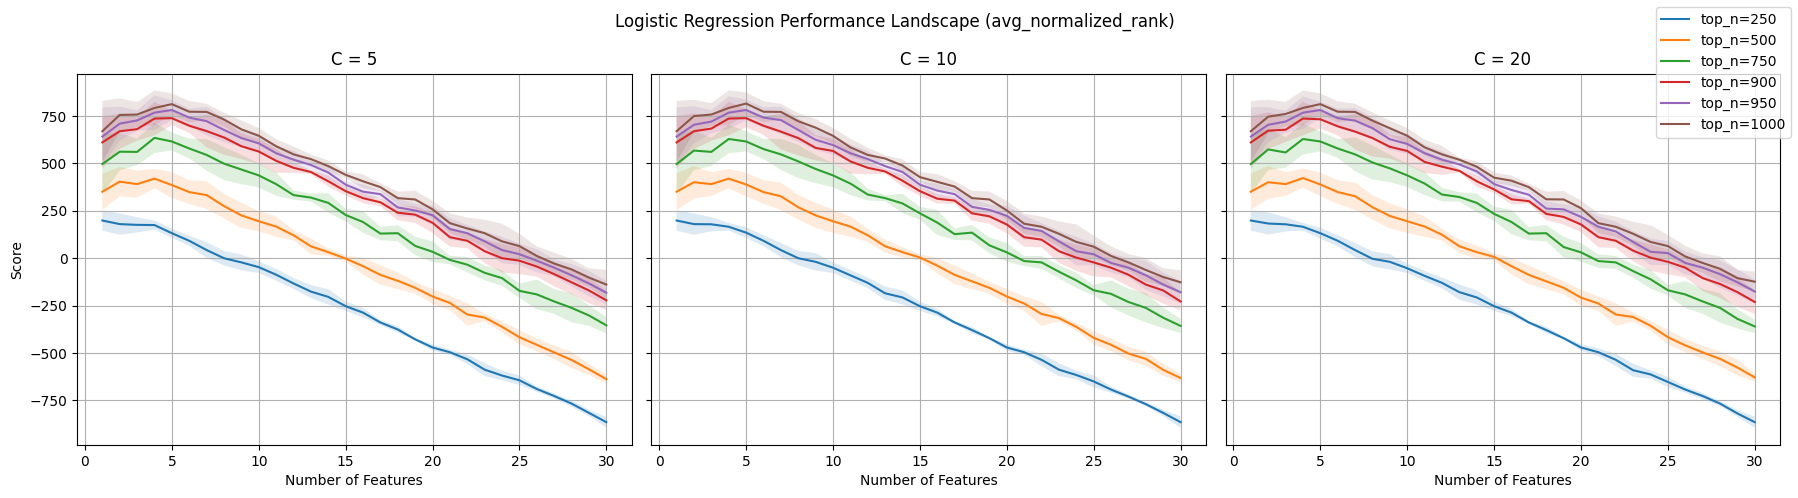

In [ ]:
plot_metric_surface(
    df=final_results,
    x_col="n_features",
    y_col="score",
    split_col="C",
    line_col="top_n",
    std_col="score_std",
    title="Logistic Regression Performance (avg_normalized_rank)",
    x_label="Number of Features",
    y_label="Score"
)

The experiments showed that feature subsets derived from `l1_rank` consistently achieved better performance than those based on the ensemble `avg_normalized_rank`. This suggests that the sparse selection mechanism of L1 regularization was particularly effective in identifying the most informative variables for Logistic Regression.

The model also consistently preferred relatively large campaign sizes, typically selecting between 950 and 1000 customers. The optimal model complexity remained very low approximately 4 features when using `l1_rank`,
and around 5 features when using `avg_normalized_rank`.